In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("../data/processed/feature_engineered.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Weekday,Hour,IsWeekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday,7,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,7,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,7,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,Tuesday,7,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,Tuesday,7,False


In [5]:
rfm = df.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Frequency", "Monetary"]

rfm.head()

,Frequency,Monetary
Customer ID,,
12346.0,15,-51.74
12347.0,2,1323.32
12348.0,1,222.16
12349.0,4,2646.99
12351.0,1,300.93


In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

latest_date = df["InvoiceDate"].max()

recency = (
    df.groupby("Customer ID")["InvoiceDate"]
      .max()
)

rfm["Recency"] = (latest_date - recency).dt.days

rfm.head()

,Frequency,Monetary,Recency
Customer ID,,,
12346.0,15,-51.74,66
12347.0,2,1323.32,2
12348.0,1,222.16,73
12349.0,4,2646.99,42
12351.0,1,300.93,10


In [7]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

In [8]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Frequency,Monetary,Recency,Cluster
Customer ID,,,,
12346.0,15,-51.74,66,0
12347.0,2,1323.32,2,0
12348.0,1,222.16,73,0
12349.0,4,2646.99,42,0
12351.0,1,300.93,10,0


In [9]:
rfm.groupby("Cluster").mean()

,Frequency,Monetary,Recency
Cluster,,,
0,4.967610,1472.681719,41.936792
1,1.902052,403.763931,243.847015
2,137.000000,141907.743333,3.888889
3,37.032787,15751.828631,11.508197


In [10]:
rfm["Cluster"].value_counts()

Cluster
0    3180
1    1072
3     122
2       9
Name: count, dtype: int64

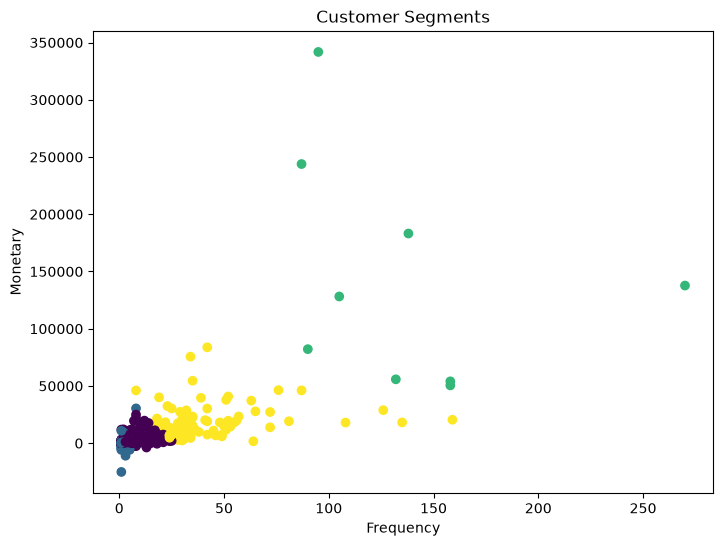

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments")

plt.show()

In [12]:
rfm.to_csv(
    "../data/processed/customer_segments.csv",
    index=True
)

print("Customer Segmentation Completed!")

Customer Segmentation Completed!
